# Drift Dashboard (BFS v0.6 Governance)
This dashboard monitors Feature Drift (PSI), Prediction Drift, and SHAP Drift by comparing the training baseline to the simulated out-of-time (OOT) test set.

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

In [2]:
def calculate_psi(expected, actual, bins=10):
    breakpoints = np.percentile(expected, np.arange(0, 101, 100/bins))
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf
    expected_percents = np.histogram(expected, breakpoints)[0] / len(expected)
    actual_percents = np.histogram(actual, breakpoints)[0] / len(actual)
    expected_percents = np.maximum(expected_percents, 0.0001)
    actual_percents = np.maximum(actual_percents, 0.0001)
    psi = (expected_percents - actual_percents) * np.log(expected_percents / actual_percents)
    return np.sum(psi)

data_dir = "../dummtdatasets/cibil_ind"
df_train = pd.read_csv(os.path.join(data_dir, "cibil_train.csv"))
df_test = pd.read_csv(os.path.join(data_dir, "cibil_test.csv"))
df_train.replace(-99999, np.nan, inplace=True)
df_test.replace(-99999, np.nan, inplace=True)

drop_cols = [
    "Approved_Flag", "PROSPECTID", "Credit_Score",
    "enq_L3m", "enq_L6m", "enq_L12m", "tot_enq", "time_since_recent_enq",
    "CC_enq", "CC_enq_L6m", "CC_enq_L12m", "PL_enq", "PL_enq_L6m", "PL_enq_L12m",
    "pct_PL_enq_L6m_of_ever", "pct_CC_enq_L6m_of_ever", "pct_PL_enq_L6m_of_L12m", "pct_CC_enq_L6m_of_L12m",
    "Age_Oldest_TL", "Age_Newest_TL",
    "time_since_recent_deliquency", "time_since_first_deliquency",
    "num_std_12mts", "num_std_6mts", "num_std", "num_times_delinquent", "max_delinquency_level",
    "recent_level_of_deliq", "max_recent_level_of_deliq",
    "CC_Flag", "PL_Flag", "HL_Flag", "GL_Flag"
]

X_train = df_train.drop(columns=[c for c in drop_cols if c in df_train.columns])
X_test = df_test.drop(columns=[c for c in drop_cols if c in df_test.columns])

cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

model = joblib.load(os.path.join(data_dir, "xgboost_cibil_calibrated.pkl"))
prob_train = model.predict_proba(X_train)[:, 1]
prob_test = model.predict_proba(X_test)[:, 1]


,Feature,PSI
0,num_times_30p_dpd,0.000046
1,pct_opened_TLs_L6m_of_L12m,0.000812
2,max_deliq_12mts,0.000199
3,AGE,0.001850
4,time_since_recent_payment,0.001364
5,Total_TL_opened_L12M,0.000636
6,Other_TL,0.001249
7,Secured_TL,0.000550


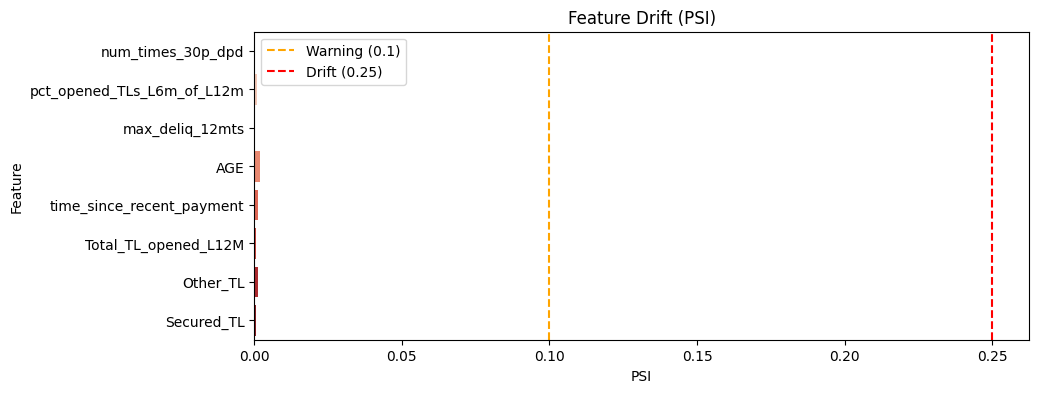

In [3]:
# 1. Feature Drift (PSI)
shap_df = pd.read_csv(os.path.join(data_dir, "shap_importance.csv"))
top_features = shap_df['feature'].head(10).tolist()

psi_results = []
for f in top_features:
    if X_train[f].dtype.name != 'category':
        psi = calculate_psi(X_train[f].dropna(), X_test[f].dropna())
        psi_results.append({'Feature': f, 'PSI': psi})

psi_df = pd.DataFrame(psi_results)
display(psi_df)

plt.figure(figsize=(10, 4))
sns.barplot(data=psi_df, x='PSI', y='Feature', palette='Reds')
plt.axvline(0.1, color='orange', linestyle='--', label='Warning (0.1)')
plt.axvline(0.25, color='red', linestyle='--', label='Drift (0.25)')
plt.title('Feature Drift (PSI)')
plt.legend()
plt.show()

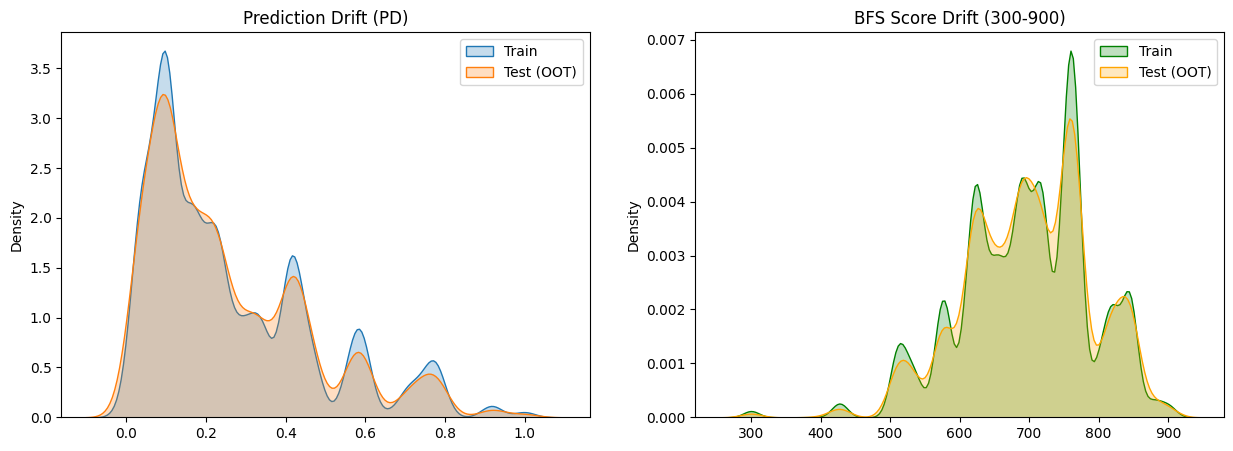

In [4]:
# 2. Prediction & Score Drift
bfs_train = np.clip(600 - 72 * np.log(prob_train / (1 - prob_train)), 300, 900)
bfs_test = np.clip(600 - 72 * np.log(prob_test / (1 - prob_test)), 300, 900)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.kdeplot(prob_train, label='Train', ax=ax1, fill=True)
sns.kdeplot(prob_test, label='Test (OOT)', ax=ax1, fill=True)
ax1.set_title('Prediction Drift (PD)')
ax1.legend()

sns.kdeplot(bfs_train, label='Train', ax=ax2, fill=True, color='green')
sns.kdeplot(bfs_test, label='Test (OOT)', ax=ax2, fill=True, color='orange')
ax2.set_title('BFS Score Drift (300-900)')
ax2.legend()
plt.show()

,Feature,SHAP_Train,SHAP_Test,Drift_Magnitude
52,last_prod_enq2,0.519286,0.505726,0.013560
42,AGE,0.164130,0.172158,0.008028
45,Time_With_Curr_Empr,0.066794,0.074408,0.007614
18,Home_TL,0.030422,0.037277,0.006855
29,num_times_30p_dpd,0.339971,0.346291,0.006320
22,Other_TL,0.093404,0.099485,0.006080
14,Auto_TL,0.030722,0.035141,0.004419
51,max_unsec_exposure_inPct,0.084673,0.088978,0.004305
1,Tot_Closed_TL,0.078646,0.082670,0.004024
23,time_since_recent_payment,0.104899,0.101108,0.003792


<Figure size 1000x600 with 0 Axes>

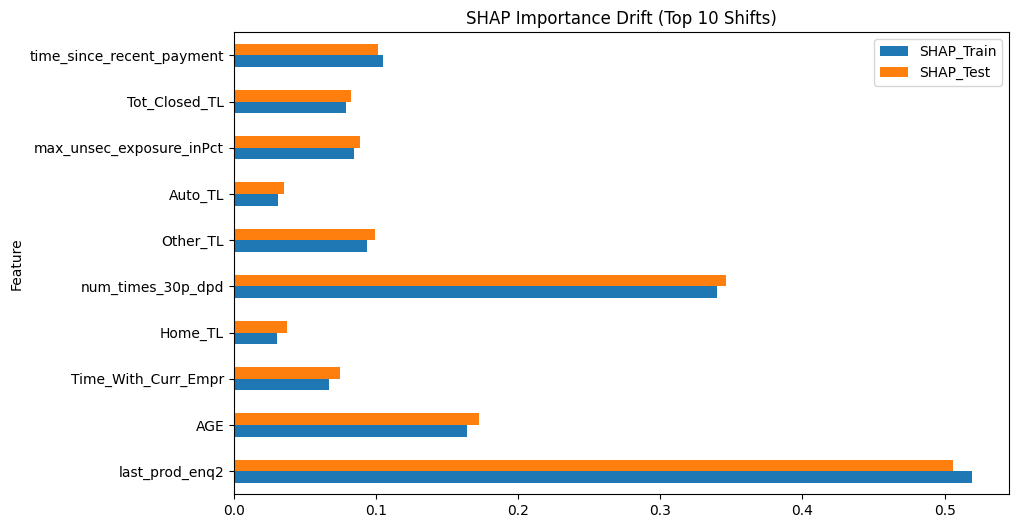

In [5]:
# 3. SHAP Drift
# Extract base XGBoost model from the CalibratedClassifierCV
base_estimator = model.estimator
if hasattr(base_estimator, 'estimator'):
    base_estimator = base_estimator.estimator # FrozenEstimator unwrapping
explainer = shap.TreeExplainer(base_estimator)

sample_train = X_train.sample(min(1000, len(X_train)), random_state=42)
sample_test = X_test.sample(min(1000, len(X_test)), random_state=42)

shap_train = np.abs(explainer.shap_values(sample_train)).mean(axis=0)
shap_test = np.abs(explainer.shap_values(sample_test)).mean(axis=0)

shap_drift = pd.DataFrame({
    'Feature': X_train.columns,
    'SHAP_Train': shap_train,
    'SHAP_Test': shap_test
})
shap_drift['Drift_Magnitude'] = np.abs(shap_drift['SHAP_Train'] - shap_drift['SHAP_Test'])
display(shap_drift.sort_values('Drift_Magnitude', ascending=False).head(10))

plt.figure(figsize=(10, 6))
top_drift = shap_drift.sort_values('Drift_Magnitude', ascending=False).head(10)
top_drift.plot(x='Feature', y=['SHAP_Train', 'SHAP_Test'], kind='barh', figsize=(10, 6))
plt.title('SHAP Importance Drift (Top 10 Shifts)')
plt.show()